#**1. Perkenalan Dataset**

Dataset yang digunakan adalah **Soil Moisture Dataset** dari Kaggle oleh amirmohammdjalili.
🔗 **Link dataset:** [kaggle.com/datasets/amirmohammdjalili/soil-moisture-dataset](https://www.kaggle.com/datasets/amirmohammdjalili/soil-moisture-dataset).

Dataset ini berisi rekaman sensor kelembaban tanah dari tiga pot tanaman yang dimonitor secara real-time menggunakan sensor IoT multi-layer.

**Konteks:**
- **vase1 / plant_vase1.CSV** : Pot bunga periode pertama
- **vase1(2) / plant_vase1(2).CSV** : Pot bunga periode kedua (pengukuran ulang)
- **vase2 / plant_vase2.CSV** : Pot berisi tanah saja (kontrol)

**Kolom utama:**
- `moisture0` – `moisture4` : Nilai kelembaban di 5 kedalaman sensor
- `year`, `month`, `day`, `hour`, `minute`, `second` : Komponen waktu pengukuran
- `irrgation` : Status irigasi (True/False) saat pengukuran berlangsung

#**2. Import Library**

Pada tahap ini dimpor beberapa pustaka (library) Python yang dibutuhkan untuk proses analisis dan visualisasi data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import kagglehub
from google.colab import files
import os
import warnings
import datetime
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

#**3. Data Loading**

Tahap ini mencakup dua langkah:
1. Upload file `kaggle.json` untuk autentikasi API.
2. Download dataset secara otomatis menggunakan `kagglehub`. Setelah itu, ketiga file CSV dibaca ke dalam DataFrame terpisah dan digabung menjadi satu DataFrame `df_all` dengan kolom `source` sebagai penanda asal data.

In [2]:
files.upload()

path = kagglehub.dataset_download("amirmohammdjalili/soil-moisture-dataset")
print("Path:", path)

Saving kaggle.json to kaggle.json
Using Colab cache for faster access to the 'soil-moisture-dataset' dataset.
Path: /kaggle/input/soil-moisture-dataset


In [3]:
df_vase1  = pd.read_csv(os.path.join(path, 'plant_vase1.CSV'))
df_vase1b = pd.read_csv(os.path.join(path, 'plant_vase1(2).CSV'))
df_vase2  = pd.read_csv(os.path.join(path, 'plant_vase2.CSV'))

In [4]:
df_vase1['source']  = 'vase1_bunga'
df_vase1b['source'] = 'vase1_bunga_2'
df_vase2['source']  = 'vase2_tanah'

In [5]:
df_all = pd.concat([df_vase1, df_vase1b, df_vase2], ignore_index=True)

print("Data berhasil digabungkan")
print(f"- vase1 (bunga)     : {len(df_vase1):,} baris")
print(f"- vase1_2 (bunga)   : {len(df_vase1b):,} baris")
print(f"- vase2 (tanah)     : {len(df_vase2):,} baris")
print(f"- Total gabungan    : {len(df_all):,} baris")

Data berhasil digabungkan
- vase1 (bunga)     : 4,117 baris
- vase1_2 (bunga)   : 4,409 baris
- vase2 (tanah)     : 10,289 baris
- Total gabungan    : 18,815 baris


# **4. Exploratory Data Analysis (EDA)**

**Exploratory Data Analysis (EDA)** adalah proses memahami struktur, distribusi, dan kualitas data sebelum diolah lebih lanjut. Pada tahap ini dilakukan :
1. Melihat sampel data (`head`)
2. Mengecek tipe data dan nilai non-null (`info`)
3. Melihat statistik deskriptif (`describe`)
4. Mendeteksi missing values dan duplikat
5. Menganalisis distribusi dan outlier tiap sensor moisture

In [6]:
df_all.head()

,year,month,day,hour,minute,second,moisture0,moisture1,moisture2,moisture3,moisture4,irrgation,source
0,2020,3,6,22,16,11,0.70,0.64,0.73,0.40,0.02,False,vase1_bunga
1,2020,3,6,22,17,11,0.70,0.64,0.71,0.39,0.02,False,vase1_bunga
2,2020,3,6,22,18,11,0.69,0.63,0.70,0.39,0.02,False,vase1_bunga
3,2020,3,6,22,19,11,0.69,0.63,0.70,0.39,0.02,False,vase1_bunga
4,2020,3,6,22,20,12,0.69,0.62,0.69,0.39,0.02,False,vase1_bunga


In [7]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18815 entries, 0 to 18814
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       18815 non-null  int64  
 1   month      18815 non-null  int64  
 2   day        18815 non-null  int64  
 3   hour       18815 non-null  int64  
 4   minute     18815 non-null  int64  
 5   second     18815 non-null  int64  
 6   moisture0  18815 non-null  float64
 7   moisture1  18815 non-null  float64
 8   moisture2  18815 non-null  float64
 9   moisture3  18815 non-null  float64
 10  moisture4  18815 non-null  float64
 11  irrgation  18815 non-null  bool   
 12  source     18815 non-null  object 
dtypes: bool(1), float64(5), int64(6), object(1)
memory usage: 1.7+ MB


In [8]:
df_all.describe(include="all")

,year,month,day,hour,minute,second,moisture0,moisture1,moisture2,moisture3,moisture4,irrgation,source
count,18815.0,18815.0,18815.000000,18815.000000,18815.000000,18815.000000,18815.000000,18815.000000,18815.000000,18815.000000,18815.000000,18815,18815
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,vase2_tanah
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18815,10289
mean,2020.0,3.0,14.558597,11.462291,29.474728,30.061334,0.335947,0.642027,0.708997,0.561985,0.015058,NaN,NaN
std,0.0,0.0,7.178824,6.941214,17.311984,16.864021,0.269700,0.228567,0.161718,0.347219,0.009634,NaN,NaN
min,2020.0,3.0,6.000000,0.000000,0.000000,0.000000,0.020000,0.140000,0.230000,0.080000,0.000000,NaN,NaN
25%,2020.0,3.0,8.000000,5.000000,15.000000,16.000000,0.080000,0.420000,0.590000,0.130000,0.010000,NaN,NaN
50%,2020.0,3.0,13.000000,11.000000,30.000000,30.000000,0.250000,0.660000,0.720000,0.650000,0.010000,NaN,NaN
75%,2020.0,3.0,21.000000,17.000000,44.000000,44.000000,0.550000,0.780000,0.840000,0.870000,0.020000,NaN,NaN


In [9]:
df_all.isnull().sum()

,0
year,0
month,0
day,0
hour,0
minute,0
second,0
moisture0,0
moisture1,0
moisture2,0
moisture3,0


In [10]:
n_duplikat = df_all.duplicated().sum()
print(f"Jumlah baris duplikat (semua kolom) : {n_duplikat}")

Jumlah baris duplikat (semua kolom) : 0


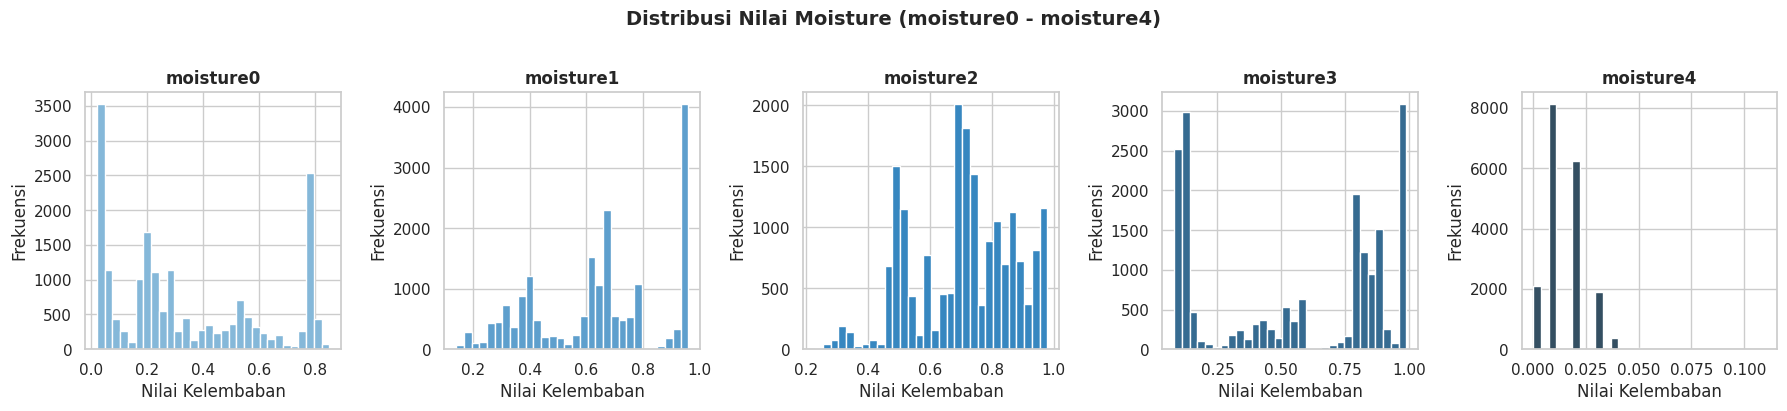

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
moisture_cols = ['moisture0', 'moisture1', 'moisture2', 'moisture3', 'moisture4']
colors = sns.color_palette("Blues_d", 5)

for i, (col, color) in enumerate(zip(moisture_cols, colors)):
  axes[i].hist(df_all[col], bins=30, color=color, edgecolor='white')
  axes[i].set_title(f'{col}', fontweight='bold')
  axes[i].set_xlabel('Nilai Kelembaban')
  axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Nilai Moisture (moisture0 - moisture4)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
for col in moisture_cols:
  Q1 = df_all[col].quantile(0.25)
  Q3 = df_all[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  n_outlier = ((df_all[col] < lower_bound) | (df_all[col] > upper_bound)).sum()
  print(f"{col}: {n_outlier} outlier terdeteksi ({n_outlier/len(df_all)*100:.2f}%)")

if n_outlier > 1:
  outliers_col = df_all[(df_all[col] < lower_bound) | (df_all[col] > upper_bound)]
  outliers_by_source = outliers_col.groupby('source').size().reset_index(name='jumlah_outlier')
  print("\n")
  print(f"Distribusi Outlier {col} berdasarkan Source:")
  print(outliers_by_source)

moisture0: 0 outlier terdeteksi (0.00%)
moisture1: 0 outlier terdeteksi (0.00%)
moisture2: 0 outlier terdeteksi (0.00%)
moisture3: 0 outlier terdeteksi (0.00%)
moisture4: 466 outlier terdeteksi (2.48%)


Distribusi Outlier moisture4 berdasarkan Source:
          source  jumlah_outlier
0  vase1_bunga_2             466


#**5. Data Preprocessing**

**Data Preprocessing** adalah tahap membersihkan dan menyiapkan data agar siap dianalisis. Langkah yang dilakukan:
1. **Handling missing values** : Diisi dengan nilai median per grup `source` agar tidak bias
2. **Menghapus duplikat** : Duplikat berdasarkan kombinasi `datetime` + `source`
3. **Parsing datetime** : Menggabungkan kolom year/month/day/hour/minute/second menjadi satu kolom `datetime`
4. **Rename kolom** : Memperbaiki typo `irrgation` → `irrigation`

In [13]:
if df_all.isnull().sum().sum() > 0:
    for col in moisture_cols:
        df_all[col] = df_all.groupby('source')[col].transform(lambda x: x.fillna(x.median()))
    print("Missing values berhasil diisi")
else:
    print("Tidak ada missing values")

Tidak ada missing values


In [14]:
df_all['datetime'] = pd.to_datetime(df_all[['year','month','day','hour','minute','second']])
df_all = df_all.sort_values(['source', 'datetime']).reset_index(drop=True)
print(f"Rentang waktu: {df_all['datetime'].min()} s/d {df_all['datetime'].max()}")

Rentang waktu: 2020-03-06 22:16:11 s/d 2020-03-29 12:03:33


In [15]:
if df_all.duplicated(subset=['datetime','source']).sum() > 0:
    df_all.drop_duplicates(subset=['datetime','source'], inplace=True)
    print("Data duplikat berhasil dihapus")
else:
    print("Tidak ada duplikat")

Tidak ada duplikat


In [16]:
df_all.rename(columns={'irrgation': 'irrigation'}, inplace=True)

In [17]:
df_all.to_csv('cleaned_data.csv', index=False)
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**6. Data Analysis**

**Data Analysis** mengekstrak insight bermakna dari data yang sudah bersih. Analisis yang dilakukan meliputi:
1.   **Statistik deskriptif** : Mean, std, min, max tiap sensor
2.   **Perbandingan antar pot** : Rata-rata moisture per sumber data
3. **Frekuensi irigasi** : Persentase waktu irigasi aktif per pot
4. **Heatmap korelasi** : Hubungan antar sensor di tiap pot
5. **Time series** : Tren kelembaban dari waktu ke waktu

In [18]:
print(df_all[moisture_cols].describe().round(3))

       moisture0  moisture1  moisture2  moisture3  moisture4
count  18815.000  18815.000  18815.000  18815.000  18815.000
mean       0.336      0.642      0.709      0.562      0.015
std        0.270      0.229      0.162      0.347      0.010
min        0.020      0.140      0.230      0.080      0.000
25%        0.080      0.420      0.590      0.130      0.010
50%        0.250      0.660      0.720      0.650      0.010
75%        0.550      0.780      0.840      0.870      0.020
max        0.850      0.960      0.980      0.990      0.110


In [19]:
print(df_all.groupby('source')[moisture_cols].mean().round(3))

               moisture0  moisture1  moisture2  moisture3  moisture4
source                                                              
vase1_bunga        0.444      0.652      0.679      0.326      0.021
vase1_bunga_2      0.228      0.414      0.477      0.124      0.026
vase2_tanah        0.339      0.736      0.820      0.844      0.008


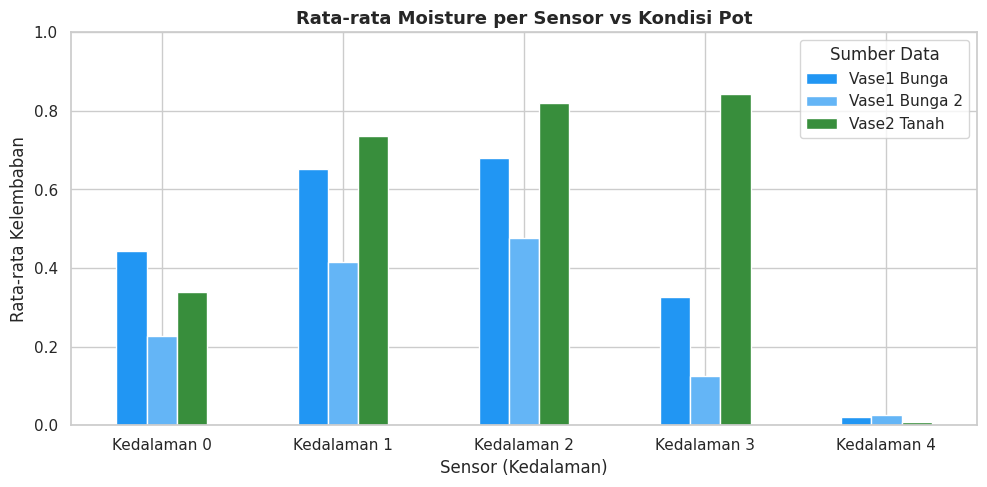

In [20]:
mean_by_source = df_all.groupby('source')[moisture_cols].mean()

fig, ax = plt.subplots(figsize=(10, 5))
mean_by_source.T.plot(kind='bar', ax=ax,
                      color=['#2196F3', '#64B5F6', '#388E3C'],
                      edgecolor='white')
ax.set_title('Rata-rata Moisture per Sensor vs Kondisi Pot',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Sensor (Kedalaman)')
ax.set_ylabel('Rata-rata Kelembaban')
ax.set_xticklabels(['Kedalaman 0','Kedalaman 1','Kedalaman 2',
                    'Kedalaman 3','Kedalaman 4'], rotation=0)
ax.legend(title='Sumber Data', labels=['Vase1 Bunga','Vase1 Bunga 2','Vase2 Tanah'])
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [21]:
irr_pct = df_all.groupby('source')['irrigation'].apply(
    lambda x: (x == True).sum() / len(x) * 100
).round(2)
print(irr_pct.to_string())

source
vase1_bunga      0.0
vase1_bunga_2    0.0
vase2_tanah      0.0


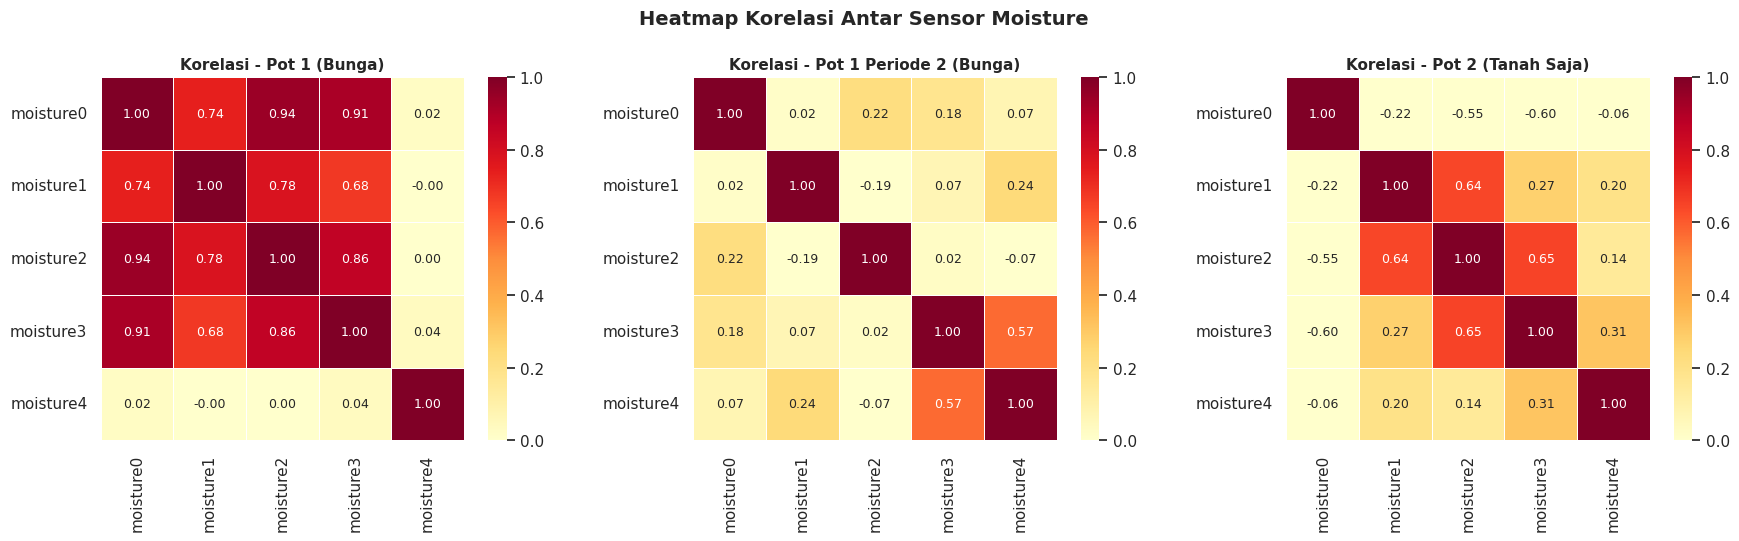

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sources = df_all['source'].unique()
titles = ['Pot 1 (Bunga)', 'Pot 1 Periode 2 (Bunga)', 'Pot 2 (Tanah Saja)']

for ax, src, title in zip(axes, sources, titles):
    subset = df_all[df_all['source'] == src][moisture_cols]
    corr = subset.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlOrRd',
                ax=ax, square=True, linewidths=0.5,
                annot_kws={'size': 9}, vmin=0, vmax=1)
    ax.set_title(f'Korelasi - {title}', fontweight='bold', fontsize=11)

plt.suptitle('Heatmap Korelasi Antar Sensor Moisture',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

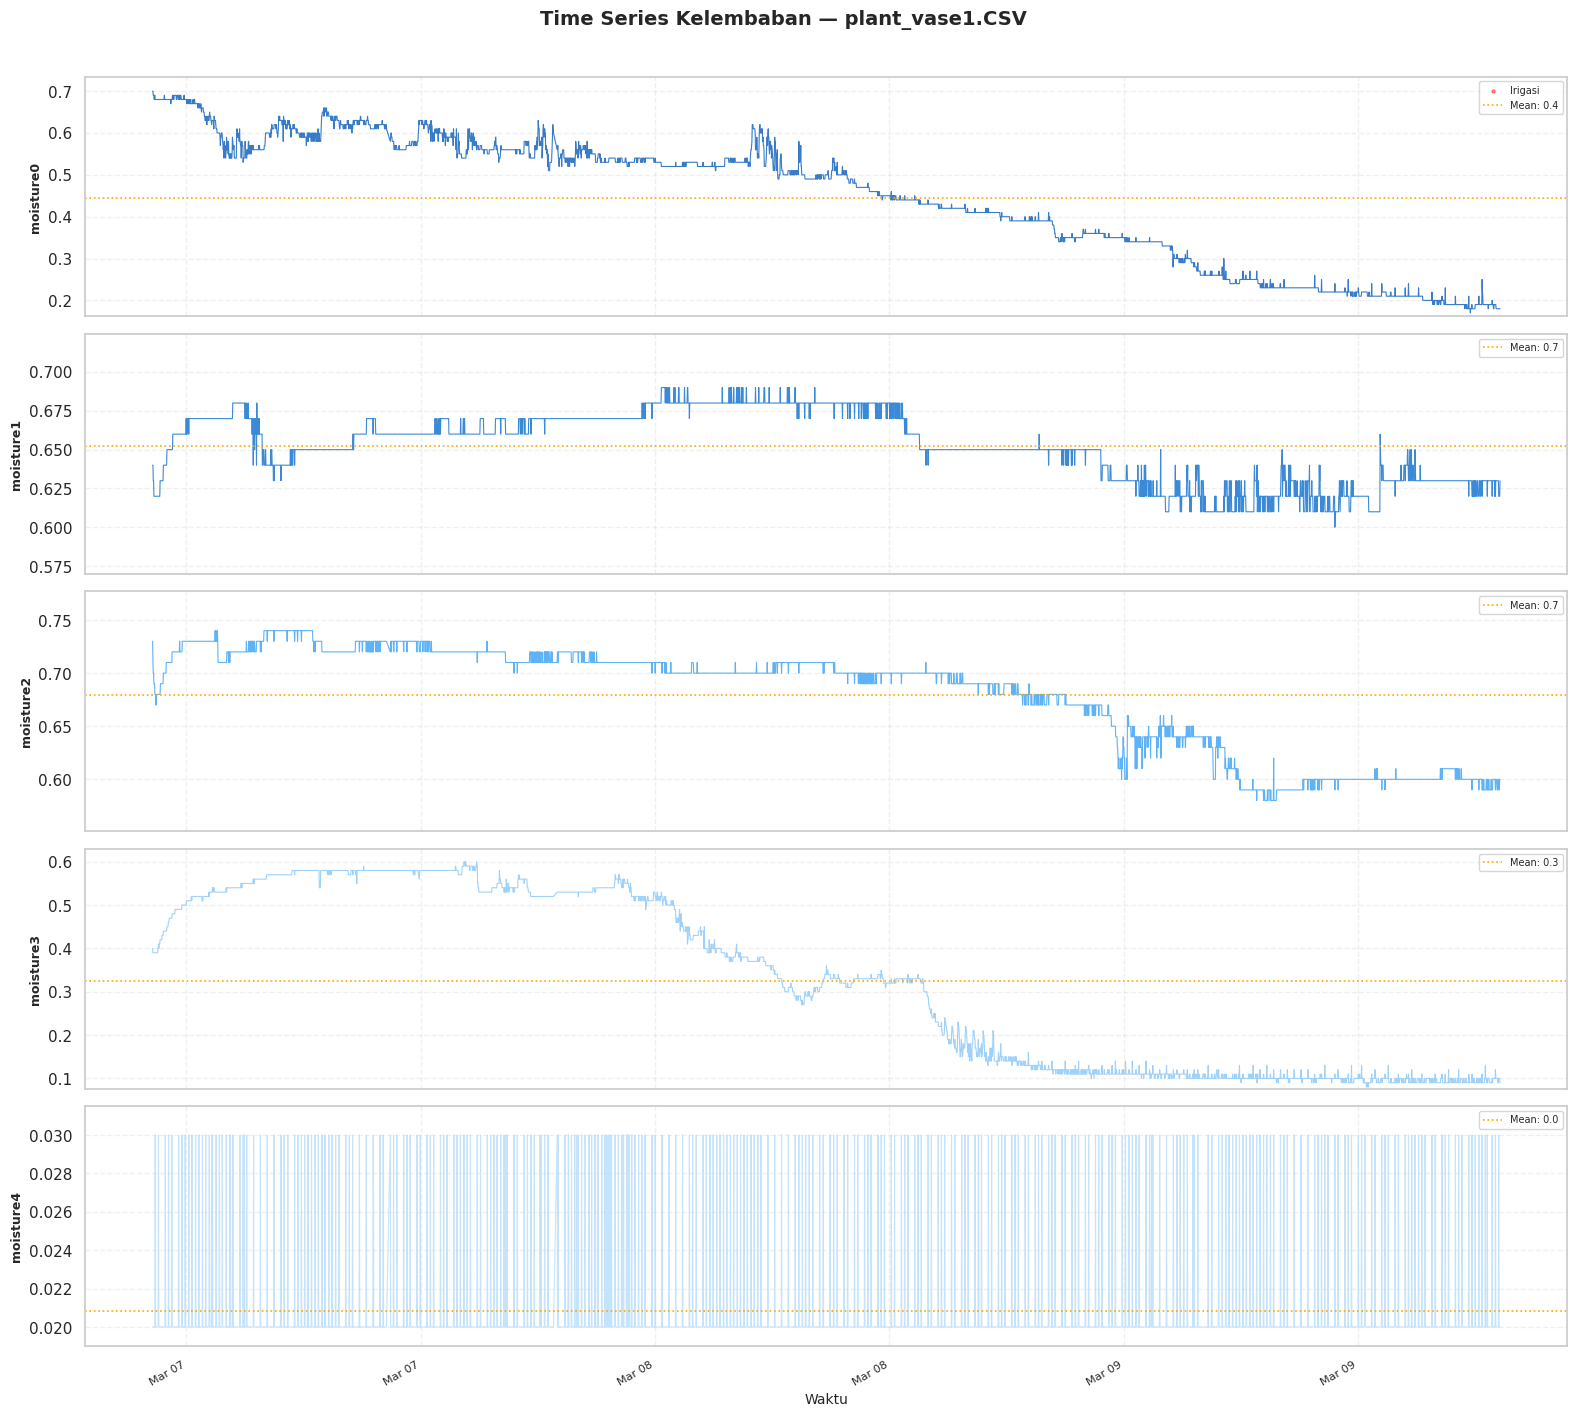


plant_vase1.CSV | Rentang: 2020-03-06 s/d 2020-03-09 | Total: 4,117 baris



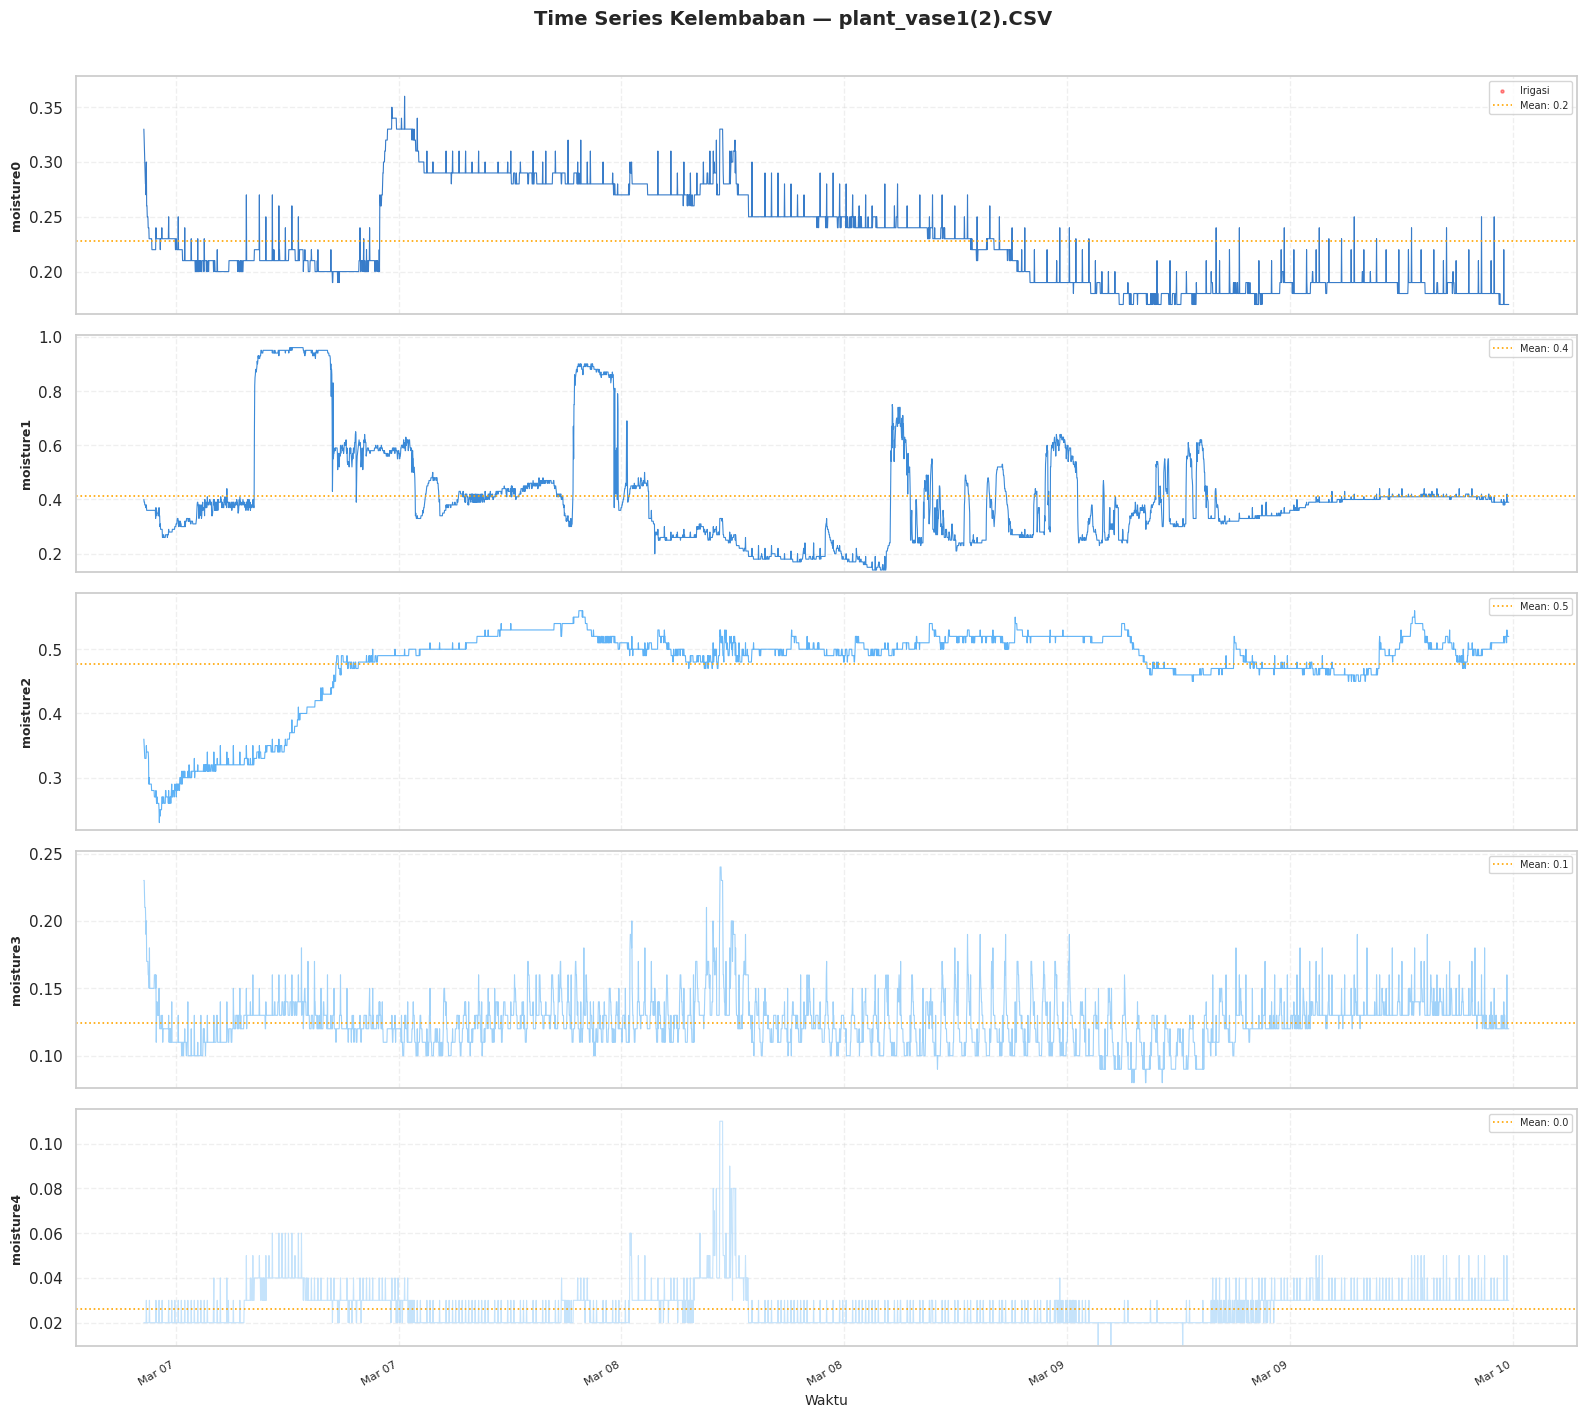


plant_vase1(2).CSV | Rentang: 2020-03-06 s/d 2020-03-09 | Total: 4,409 baris



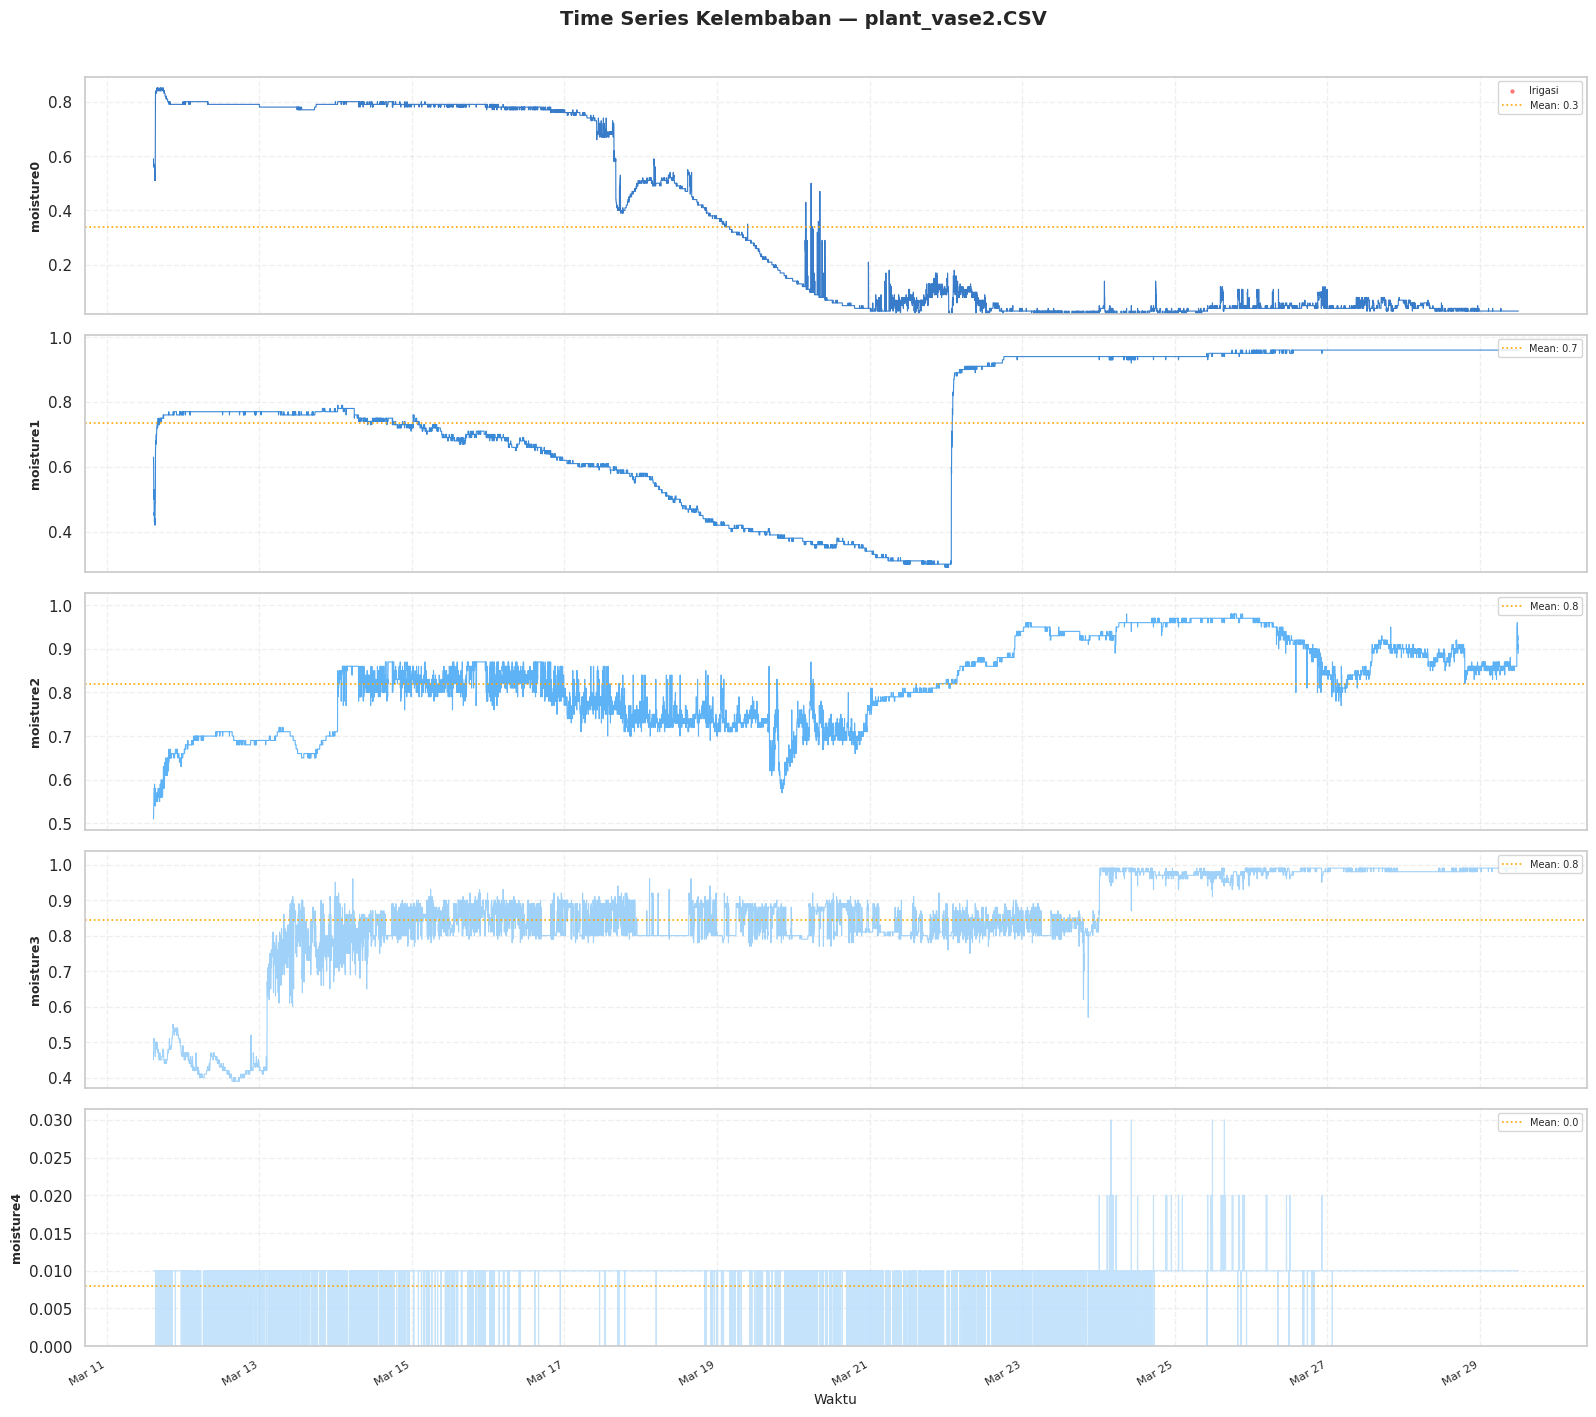


plant_vase2.CSV | Rentang: 2020-03-11 s/d 2020-03-29 | Total: 10,289 baris



In [23]:
sources_info = [
    ('vase1_bunga',   'plant_vase1.CSV'),
    ('vase1_bunga_2', 'plant_vase1(2).CSV'),
    ('vase2_tanah',   'plant_vase2.CSV')
]

moisture_cols = ['moisture0', 'moisture1', 'moisture2', 'moisture3', 'moisture4']
colors = ['#1565C0', '#1976D2', '#42A5F5', '#90CAF9', '#BBDEFB']

for src_key, src_label in sources_info:
    subset = df_all[df_all['source'] == src_key].sort_values('datetime')

    fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)
    fig.suptitle(f'Time Series Kelembaban — {src_label}',
                 fontsize=14, fontweight='bold', y=1.01)

    for i, (col, color) in enumerate(zip(moisture_cols, colors)):
        ax = axes[i]
        ax.plot(subset['datetime'], subset[col], color=color, linewidth=0.8, alpha=0.85)

        irr = subset[subset['irrigation'] == True]
        ax.scatter(irr['datetime'], irr[col], color='red', s=5, alpha=0.4, label='Irigasi' if i==0 else '')

        ax.set_ylabel(f'{col}', fontsize=9, fontweight='bold')
        ax.set_ylim(subset[col].min() * 0.95, subset[col].max() * 1.05)
        ax.grid(True, alpha=0.3, linestyle='--')

        mean_val = subset[col].mean()
        ax.axhline(mean_val, color='orange', linestyle=':', linewidth=1.2,
                   label=f'Mean: {mean_val:.1f}')
        ax.legend(loc='upper right', fontsize=7)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=30, ha='right', fontsize=8)
    axes[-1].set_xlabel('Waktu', fontsize=10)

    plt.tight_layout()
    plt.show()
    print(f"\n{src_label} | Rentang: {subset['datetime'].min().date()} s/d {subset['datetime'].max().date()} | Total: {len(subset):,} baris\n")

# **7. Data Quality Score**

**Data Quality Score (DQS)** adalah metrik kuantitatif untuk mengukur seberapa baik kualitas dataset kita.

- **Accuracy** = 1 − (jumlah missing / total data) → mengukur kelengkapan nilai
- **Completeness** = proporsi baris non-null terhadap total → mengukur seberapa penuh data
- **Timeliness** = proporsi data yang masuk dalam 30 hari terakhir dari tanggal terbaru

Score keseluruhan adalah rata-rata dari ketiga dimensi tersebut.

In [24]:
total_cells  = df_all[moisture_cols].size
missing_vals = df_all[moisture_cols].isnull().sum().sum()
non_null_rows = df_all.dropna(subset=moisture_cols).shape[0]
total_rows   = len(df_all)

# Accuracy
accuracy = 1 - (missing_vals / total_cells)

# Completeness
completeness = non_null_rows / total_rows

# Timeliness
max_date = df_all['datetime'].max()
cutoff   = max_date - pd.Timedelta(days=30)
timely   = df_all[df_all['datetime'] >= cutoff].shape[0]
timeliness = timely / total_rows

# Overall DQS
dqs_overall = (accuracy + completeness + timeliness) / 3

print("=" * 50)
print("       DATA QUALITY SCORE REPORT")
print("=" * 50)

print(f"  Total baris   : {total_rows:,}")
print(f"  Tanggal maks  : {max_date.date()}")
print(f"  Cutoff 30hr   : {cutoff.date()}")
print(f"  Accuracy      : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Completeness  : {completeness:.4f}  ({completeness*100:.2f}%)")
print(f"  Timeliness    : {timeliness:.4f}  ({timeliness*100:.2f}%)")
print("-" * 50)
print(f"  Overall DQS   : {dqs_overall:.4f}  ({dqs_overall*100:.2f}%)")
print("=" * 50)

       DATA QUALITY SCORE REPORT
  Total baris   : 18,815
  Tanggal maks  : 2020-03-29
  Cutoff 30hr   : 2020-02-28
  Accuracy      : 1.0000  (100.00%)
  Completeness  : 1.0000  (100.00%)
  Timeliness    : 1.0000  (100.00%)
--------------------------------------------------
  Overall DQS   : 1.0000  (100.00%)
